In [28]:
import os
import shutil
from PIL import Image
import kagglehub

# Define the target directory where we want the dataset to reside
target_dataset_dir = "/content/emnist-digits-balanced"

# Clean up previous attempts if the directory exists
if os.path.exists(target_dataset_dir):
    print(f"Removing existing directory: {target_dataset_dir}")
    shutil.rmtree(target_dataset_dir)

# Create the target directory
os.makedirs(target_dataset_dir)

# Download dataset using kagglehub
# This usually downloads to a path like /kaggle/input/<dataset_name>
downloaded_path_from_kaggle = kagglehub.dataset_download("osamaaslam86004/emnist-digits-balanced")

# Move contents (train and test subdirectories) from the KaggleHub download path to our target directory
# The 'train' and 'test' folders are directly inside the path returned by kagglehub.dataset_download.
print(f"Moving contents from {downloaded_path_from_kaggle} to {target_dataset_dir}")
shutil.move(os.path.join(downloaded_path_from_kaggle, "train"), target_dataset_dir)
shutil.move(os.path.join(downloaded_path_from_kaggle, "test"), target_dataset_dir)

# Update the 'path' variable to reflect the new location
path = target_dataset_dir
print("Path to dataset files:", path)

100%|██████████| 152M/152M [00:01<00:00, 119MB/s]

Extracting files...


Moving contents from /root/.cache/kagglehub/datasets/osamaaslam86004/emnist-digits-balanced/versions/1 to /content/emnist-digits-balanced
Path to dataset files: /content/emnist-digits-balanced


### Analyzing image properties

In [29]:
image_files = []

# Construct the correct path to the 'train' directory within the downloaded dataset
train_data_path = os.path.join(path, "train", "0")

for root, _, files in os.walk(train_data_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            image_files.append(os.path.join(root, file))

if not image_files:
    print(f"No image files found in {train_data_path}")
else:
    # Take the first image to inspect format and channels
    first_image_path = image_files[0]
    img = Image.open(first_image_path)
    print(f"Example image: {first_image_path}")
    print(f"Image format: {img.format}")
    print(f"Image mode (channels): {img.mode}") # 'RGB', 'L' (grayscale), etc.

    # Check dimensions
    dimensions = {}
    consistent_dimensions = True
    first_width, first_height = img.size

    for img_path in image_files:
        try:
            with Image.open(img_path) as current_img:
                current_width, current_height = current_img.size
                if (current_width, current_height) not in dimensions:
                    dimensions[(current_width, current_height)] = 0
                dimensions[(current_width, current_height)] += 1

                if (current_width, current_height) != (first_width, first_height):
                    consistent_dimensions = False
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")

    print("\nDimension summary:")
    for dim, count in dimensions.items():
        print(f"  {dim[0]}x{dim[1]}: {count} images")

    if consistent_dimensions:
        print(f"\nAll images have the same dimensions: {first_width}x{first_height}")
    else:
        print("\nImages have varying dimensions.")

Example image: /content/emnist-digits-balanced/train/0/12559.png
Image format: PNG
Image mode (channels): L

Dimension summary:
  28x28: 24000 images

All images have the same dimensions: 28x28


### Resizing all images to 224x224

In [31]:
from PIL import Image
import os

def resize_image(image_path, size=(224, 224)):
    try:
        img = Image.open(image_path)
        # Resize with a high-quality filter for better results
        img_resized = img.resize(size, Image.LANCZOS)
        img_resized.save(image_path) # Overwrite the original image
    except Exception as e:
        print(f"Could not resize image {image_path}: {e}")

def resize_dataset_split(image_path_split):
  image_files = [] # Initialize image_files for each call to avoid accumulation
  for root, _, files in os.walk(image_path_split):
      for file in files:
          if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
              image_files.append(os.path.join(root, file))

  print(f"Resizing {len(image_files)} images in {image_path_split}...")

  for i, img_path in enumerate(image_files):
      resize_image(img_path)
      if (i + 1) % 10000 == 0:
          print(f"Processed {i + 1}/{len(image_files)} images...")

  print(f"Image resizing complete for {image_path_split}.")

  # Verify the dimensions of a sample image after resizing
  if image_files:
      sample_image_path = image_files[0]
      with Image.open(sample_image_path) as img:
          print(f"\nSample image {os.path.basename(sample_image_path)} new dimensions: {img.size}")


print("Resizing train split....")
train_set_path = "/content/emnist-digits-balanced/train"
resize_dataset_split(train_set_path)

print("Resizing test split....")
test_set_path = "/content/emnist-digits-balanced//test"
resize_dataset_split(test_set_path)

Resizing train split....
Resizing 240000 images in /content/emnist-digits-balanced/train...
Processed 10000/240000 images...
Processed 20000/240000 images...
Processed 30000/240000 images...
Processed 40000/240000 images...
Processed 50000/240000 images...
Processed 60000/240000 images...
Processed 70000/240000 images...
Processed 80000/240000 images...
Processed 90000/240000 images...
Processed 100000/240000 images...
Processed 110000/240000 images...
Processed 120000/240000 images...
Processed 130000/240000 images...
Processed 140000/240000 images...
Processed 150000/240000 images...
Processed 160000/240000 images...
Processed 170000/240000 images...
Processed 180000/240000 images...
Processed 190000/240000 images...
Processed 200000/240000 images...
Processed 210000/240000 images...
Processed 220000/240000 images...
Processed 230000/240000 images...
Processed 240000/240000 images...
Image resizing complete for /content/emnist-digits-balanced/train.

Sample image 12559.png new dimens

In [32]:
import os

def count_image_files(directory_path):
    count = 0
    for root, _, files in os.walk(directory_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                count += 1
    return count

train_set_path = os.path.join(path, "train")
test_set_path = os.path.join(path, "test")

train_samples = count_image_files(train_set_path)
test_samples = count_image_files(test_set_path)

print(f"Total samples in the training set: {train_samples}")
print(f"Total samples in the test set: {test_samples}")

Total samples in the training set: 240000
Total samples in the test set: 40000


#### Split Train Set Into Train And Validation Set

In [33]:
import gdown
import os
import shutil
from sklearn.model_selection import train_test_split

# Define base directories
extract_dir = '/content/emnist-digits-balanced'
source_data_dir = os.path.join(extract_dir, 'train')

# Define new parent directories for the split data
base_output_dir = 'emnist_split_data'
train_output_dir = os.path.join(base_output_dir, 'train')
val_output_dir = os.path.join(base_output_dir, 'val')

# Create the new directories if they don't exist
os.makedirs(train_output_dir, exist_ok=True)
os.makedirs(val_output_dir, exist_ok=True)

# Iterate through each digit class (0-9)
for digit_class in range(10):
    class_source_dir = os.path.join(source_data_dir, str(digit_class))

    # Create class-specific directories in the new train/val structure
    class_train_target_dir = os.path.join(train_output_dir, str(digit_class))
    class_val_target_dir = os.path.join(val_output_dir, str(digit_class))
    os.makedirs(class_train_target_dir, exist_ok=True)
    os.makedirs(class_val_target_dir, exist_ok=True)

    # Get all image files for the current digit class
    image_files = [os.path.join(class_source_dir, f) for f in os.listdir(
        class_source_dir) if f.endswith(
            ('.png', '.jpg', '.jpeg'))]

    # Split the files into training and validation sets
    train_files, val_files = train_test_split(image_files, test_size=0.2,
                                              random_state=42, shuffle=True)

    print(f"Processing class {digit_class}: {len(train_files)} \
    training images, {len(val_files)} validation images")

    # Move training files
    for f in train_files:
        shutil.move(f, class_train_target_dir)

    # Move validation files
    for f in val_files:
        shutil.move(f, class_val_target_dir)

print("Data splitting complete. Original training images have been moved to new train/val directories.")


Processing class 0: 19200     training images, 4800 validation images
Processing class 1: 19200     training images, 4800 validation images
Processing class 2: 19200     training images, 4800 validation images
Processing class 3: 19200     training images, 4800 validation images
Processing class 4: 19200     training images, 4800 validation images
Processing class 5: 19200     training images, 4800 validation images
Processing class 6: 19200     training images, 4800 validation images
Processing class 7: 19200     training images, 4800 validation images
Processing class 8: 19200     training images, 4800 validation images
Processing class 9: 19200     training images, 4800 validation images
Data splitting complete. Original training images have been moved to new train/val directories.


#### Move Test Set

In [37]:
!mv /content/emnist-digits-balanced/test /content/emnist_split_data

###

The original `/content/train` directory is now empty or contains only non-image files, as images were moved to `emnist_split_data/train` and `emnist_split_data/val`.


#### Extracting Masks

In [40]:
import numpy as np
import os
from PIL import Image

def extract_mask(image_path):
    """
    Extracts a binary mask from an image. Assumes digits are dark on a light background.
    """
    img = Image.open(image_path).convert('L') # Ensure grayscale
    # Convert image to numpy array for processing
    img_array = np.array(img)

    # Apply a simple threshold to create a binary mask
    # Adjust the threshold value as needed based on image characteristics.
    # Based on user feedback, if images produced black digits on white background,
    # this inversion (checking for >= threshold) will make digits white on a black background.
    threshold = 128 # Example threshold value
    mask_array = (img_array >= threshold).astype(np.uint8) * 255 # Convert to 0/255 for binary image (light pixels become white)

    return Image.fromarray(mask_array) # Return mask as a PIL Image, 'L' mode is inferred



output_mask_dir = "/content/emnist_split_data_masks"
os.makedirs(output_mask_dir, exist_ok=True)

print(f"Masks will be saved to: {output_mask_dir}")


def extract_mask_main(image_path_split, split_name):
  image_files = [] # Initialize image_files for each call to avoid accumulation
  for root, _, files in os.walk(image_path_split):
      for file in files:
          if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
              image_files.append(os.path.join(root, file))

  print(f"Generating masks for {len(image_files)} images in {image_path_split} ({split_name} split)....")

  # Process and save masks
  for img_path in image_files:
      try:
          # Extract digit class from the image path (e.g., /content/synthetic_digits_v5/9/1196.png -> 9)
          digit_class = os.path.basename(os.path.dirname(img_path))

          # Create subdirectory for the split and then for the digit class
          class_output_dir = os.path.join(output_mask_dir, split_name, digit_class)
          os.makedirs(class_output_dir, exist_ok=True)

          # Extract mask
          mask_img = extract_mask(img_path)

          # Define output path for the mask
          mask_filename = os.path.basename(img_path).replace('.png', '_mask.png') # Example naming
          mask_output_path = os.path.join(class_output_dir, mask_filename)

          # Save the mask
          mask_img.save(mask_output_path)

      except Exception as e:
          print(f"Could not process image {img_path} for mask extraction: {e}")

  print(f"Mask extraction and saving complete for {split_name} split.")

  # Verify a few generated masks
  print(f"\nContents of a sample digit class folder in {os.path.join(output_mask_dir, split_name)}:")
  sample_digit_class_path = os.path.join(output_mask_dir, split_name, '0') # Assuming '0' is a digit class
  if os.path.exists(sample_digit_class_path):
      print(os.listdir(sample_digit_class_path)[:5]) # Print first 5 mask filenames
  else:
      print(f"Directory {sample_digit_class_path} not found.")



print("Generating Masks for train split....")
train_set_path = "/content/emnist_split_data/train"
extract_mask_main(train_set_path, "train")

print("Generating Masks for val split....")
val_set_path = "/content/emnist_split_data/val"
extract_mask_main(val_set_path, "val")

print("Generating Masks for test split....")
test_set_path = "/content/emnist_split_data/test"
extract_mask_main(test_set_path, "test")

Masks will be saved to: /content/emnist_split_data_masks
Generating Masks for train split....
Generating masks for 192000 images in /content/emnist_split_data/train (train split)....
Mask extraction and saving complete for train split.

Contents of a sample digit class folder in /content/emnist_split_data_masks/train:
['08807_mask.png', '01241_mask.png', '01032_mask.png', '03953_mask.png', '04382_mask.png']
Generating Masks for val split....
Generating masks for 48000 images in /content/emnist_split_data/val (val split)....
Mask extraction and saving complete for val split.

Contents of a sample digit class folder in /content/emnist_split_data_masks/val:
['09487_mask.png', '04794_mask.png', '16182_mask.png', '21216_mask.png', '10175_mask.png']
Generating Masks for test split....
Generating masks for 40000 images in /content/emnist_split_data/test (test split)....
Mask extraction and saving complete for test split.

Contents of a sample digit class folder in /content/emnist_split_data_m

### Extracting Bounding Boxes from Simple Masks (`/content/emnist_split_data_masks`)

In [41]:
import cv2
import numpy as np
import pandas as pd
import os
from PIL import Image

def get_bboxes_from_simple_masks(mask_base_dir, original_image_base_dir, split_name):
    """
    Extracts bounding boxes from binary masks and links them to original image paths.

    Args:
        mask_base_dir (str): Base directory containing mask splits (e.g., '/content/emnist_split_data_masks').
        original_image_base_dir (str): Base directory containing original image splits (e.g., '/content/emnist_split_data').
        split_name (str): The name of the split (e.g., 'train', 'val', 'test').

    Returns:
        pd.DataFrame: DataFrame containing bounding box data.
    """
    split_mask_dir = os.path.join(mask_base_dir, split_name)
    output_bbox_file = f"/content/simple_masks_bounding_boxes_{split_name}.csv"

    bounding_box_data = []
    problematic_masks = []

    mask_files = []
    for root, _, files in os.walk(split_mask_dir):
        for file in files:
            if file.lower().endswith(('_mask.png')):
                mask_files.append(os.path.join(root, file))

    print(f"Processing {len(mask_files)} masks in {split_mask_dir} ({split_name} split)...")

    for i, mask_path in enumerate(mask_files):
        try:
            # Extract digit class from mask path (e.g., /.../train/0/123_mask.png -> '0')
            digit_class = os.path.basename(os.path.dirname(mask_path))

            # Reconstruct original image filename (e.g., 123_mask.png -> 123.png)
            original_filename = os.path.basename(mask_path).replace('_mask.png', '.png')

            # Reconstruct original image path
            original_image_path = os.path.join(original_image_base_dir, split_name, digit_class, original_filename)

            # Load the mask image
            mask_img_cv = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask_img_cv is None:
                print(f"Warning: Could not read mask image {mask_path}. Skipping.")
                problematic_masks.append((mask_path, "Could not read mask"))
                continue

            # Ensure it's treated as a binary image for contour finding
            # Masks should ideally be 0 or 255. Thresholding just to be safe.
            _, binary_mask = cv2.threshold(mask_img_cv, 1, 255, cv2.THRESH_BINARY)

            # Find contours
            results = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            contours = []
            if len(results) >= 2:
                if len(results) == 3:
                    contours = results[1]
                else:
                    contours = results[0]

            bbox_coords = [0, 0, 0, 0] # xmin, ymin, xmax, ymax
            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(largest_contour)
                bbox_coords = [x, y, x + w, y + h]
            else:
                # If no contours found, it might be an empty mask or completely white/black
                print(f"Warning: No contours found for mask {mask_path}. Setting bbox to [0,0,0,0].")

            bounding_box_data.append({
                'image_path': original_image_path,
                'digit_class': digit_class,
                'mask_path': mask_path,
                'bbox_xmin': bbox_coords[0],
                'bbox_ymin': bbox_coords[1],
                'bbox_xmax': bbox_coords[2],
                'bbox_ymax': bbox_coords[3]
            })

        except Exception as e:
            print(f"Could not process mask {mask_path} for bounding box extraction: {e}")
            problematic_masks.append((mask_path, str(e)))

        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1}/{len(mask_files)} masks...")

    print(f"\nBounding box extraction from simple masks complete for {split_name} split.")

    if problematic_masks:
        print(f"\n{len(problematic_masks)} masks could not be processed. Here are some details:")
        for p_file, p_error in problematic_masks[:5]:
            print(f"  Mask: {p_file}, Error: {p_error}")
        if len(problematic_masks) > 5:
            print("  ...")

    bbox_df = pd.DataFrame(bounding_box_data)
    bbox_df.to_csv(output_bbox_file, index=False)
    print(f"Bounding box data saved to: {output_bbox_file}")

    return bbox_df


# Define base directories for masks and original images
mask_base_dir = "/content/emnist_split_data_masks"
original_image_base_dir = "/content/emnist_split_data"

# Process train split
print("\n--- Processing Train Split Masks ---")
train_bbox_df_simple = get_bboxes_from_simple_masks(mask_base_dir, original_image_base_dir, "train")

# Process validation split
print("\n--- Processing Validation Split Masks ---")
val_bbox_df_simple = get_bboxes_from_simple_masks(mask_base_dir, original_image_base_dir, "val")

# Process test split
print("\n--- Processing Test Split Masks ---")
test_bbox_df_simple = get_bboxes_from_simple_masks(mask_base_dir, original_image_base_dir, "test")

print("\nSample Bounding Box Data from simple masks (train split):")
display(train_bbox_df_simple.head())


--- Processing Train Split Masks ---
Processing 192000 masks in /content/emnist_split_data_masks/train (train split)...
Processed 10000/192000 masks...
Processed 20000/192000 masks...
Processed 30000/192000 masks...
Processed 40000/192000 masks...
Processed 50000/192000 masks...
Processed 60000/192000 masks...
Processed 70000/192000 masks...
Processed 80000/192000 masks...
Processed 90000/192000 masks...
Processed 100000/192000 masks...
Processed 110000/192000 masks...
Processed 120000/192000 masks...
Processed 130000/192000 masks...
Processed 140000/192000 masks...
Processed 150000/192000 masks...
Processed 160000/192000 masks...
Processed 170000/192000 masks...
Processed 180000/192000 masks...
Processed 190000/192000 masks...

Bounding box extraction from simple masks complete for train split.
Bounding box data saved to: /content/simple_masks_bounding_boxes_train.csv

--- Processing Validation Split Masks ---
Processing 48000 masks in /content/emnist_split_data_masks/val (val split)

,image_path,digit_class,mask_path,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax
0,/content/emnist_split_data/train/9/08807.png,9,/content/emnist_split_data_masks/train/9/08807...,52,18,170,208
1,/content/emnist_split_data/train/9/01241.png,9,/content/emnist_split_data_masks/train/9/01241...,48,20,177,204
2,/content/emnist_split_data/train/9/01032.png,9,/content/emnist_split_data_masks/train/9/01032...,49,21,175,204
3,/content/emnist_split_data/train/9/03953.png,9,/content/emnist_split_data_masks/train/9/03953...,36,20,192,200
4,/content/emnist_split_data/train/9/04382.png,9,/content/emnist_split_data_masks/train/9/04382...,64,20,164,204


#### Visualizing Sample Bounding Boxes from Simple Masks

Plotting sample from Train Set:


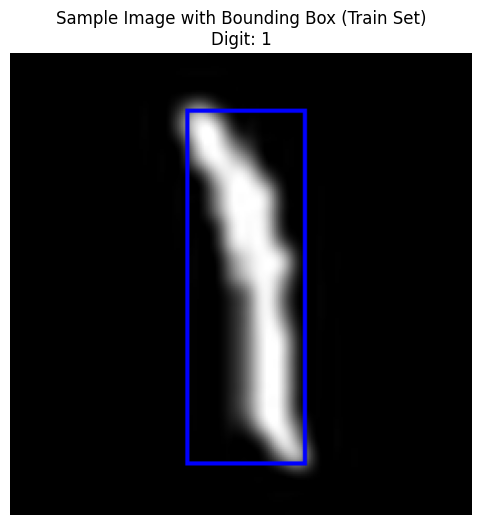

Plotting sample from Validation Set:


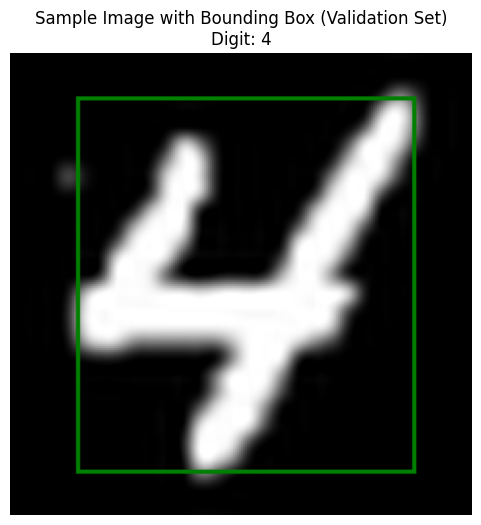

Plotting sample from Test Set:


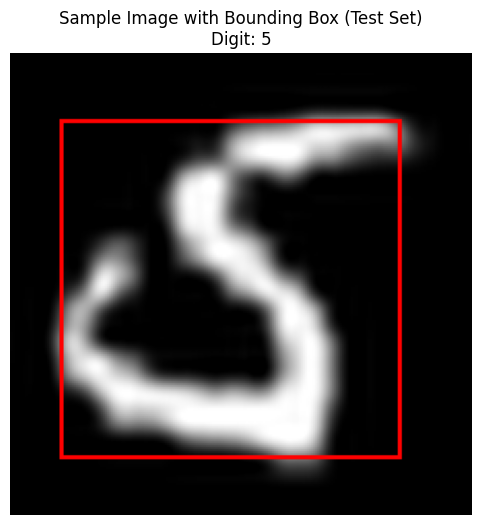

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import random


def plot_sample_with_bbox(sample_entry, split_name, color="red"):
    """Plots a random sample image with its bounding box from the given DataFrame."""

    image_path = sample_entry['image_path']
    bbox_xmin = sample_entry['bbox_xmin']
    bbox_ymin = sample_entry['bbox_ymin']
    bbox_xmax = sample_entry['bbox_xmax']
    bbox_ymax = sample_entry['bbox_ymax']

    img = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    draw.rectangle([bbox_xmin, bbox_ymin, bbox_xmax, bbox_ymax],
                   outline=color, width=2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Sample Image with Bounding Box ({split_name} Set)\nDigit: {sample_entry['digit_class']}")
    plt.axis('off')
    plt.show()


print("Plotting sample from Train Set:")
train_bbox_df_simple = pd.read_csv('/content/simple_masks_bounding_boxes_train.csv')
sample_entry = train_bbox_df_simple.sample(1).iloc[0]
plot_sample_with_bbox(sample_entry, "Train", color="blue")

print("Plotting sample from Validation Set:")
val_bbox_df_simple = pd.read_csv('/content/simple_masks_bounding_boxes_val.csv')
sample_entry = val_bbox_df_simple.sample(1).iloc[0]
plot_sample_with_bbox(sample_entry, "Validation", color="green")

print("Plotting sample from Test Set:")
test_bbox_df_simple = pd.read_csv('/content/simple_masks_bounding_boxes_test.csv')
sample_entry = val_bbox_df_simple.sample(1).iloc[0]
plot_sample_with_bbox(sample_entry, "Test", color="red")

#### Descriptive statistics for Bounding Box Heights:


Descriptive statistics for Bounding Box Widths:


,bbox_width
count,192000.000000
mean,137.085359
std,33.838570
min,17.000000
25%,117.000000
50%,140.000000
75%,164.000000
max,213.000000



Descriptive statistics for Bounding Box Heights:


,bbox_height
count,192000.000000
mean,175.369469
std,14.800753
min,25.000000
25%,172.000000
50%,178.000000
75%,184.000000
max,201.000000


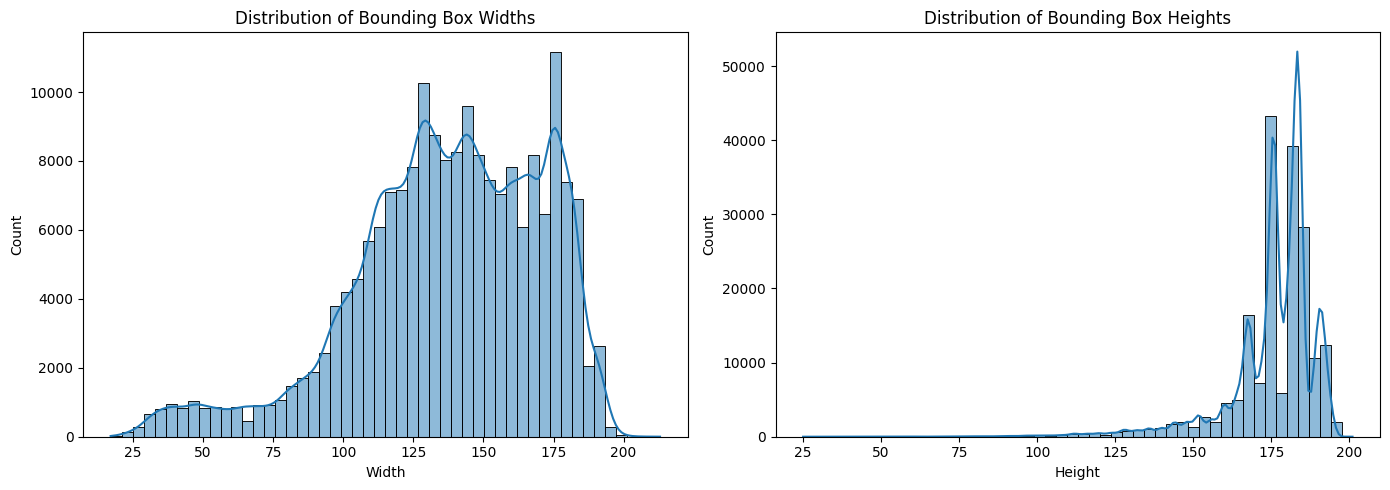

In [ ]:
# read simple_mask_bounding_box_train.csv
train_bbox_df_simple = pd.read_csv('/content/simple_masks_bounding_boxes_train.csv')

# Calculate width and height of bounding boxes
# These calculations are added here to ensure the columns exist, even if the previous cell was not run.
train_bbox_df_simple['bbox_width'] = train_bbox_df_simple['bbox_xmax'] - train_bbox_df_simple['bbox_xmin']
train_bbox_df_simple['bbox_height'] = train_bbox_df_simple['bbox_ymax'] - train_bbox_df_simple['bbox_ymin']

# Display descriptive statistics for bounding box dimensions
print("Descriptive statistics for Bounding Box Widths:")
display(train_bbox_df_simple['bbox_width'].describe())

print("\nDescriptive statistics for Bounding Box Heights:")
display(train_bbox_df_simple['bbox_height'].describe())

# Visualize the distribution of widths and heights to help identify outliers
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_bbox_df_simple['bbox_width'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Bounding Box Widths')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Count')

sns.histplot(train_bbox_df_simple['bbox_height'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Bounding Box Heights')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate width and height for train_bbox_df_simple
train_bbox_df_simple['bbox_width'] = train_bbox_df_simple['bbox_xmax'] - train_bbox_df_simple['bbox_xmin']
train_bbox_df_simple['bbox_height'] = train_bbox_df_simple['bbox_ymax'] - train_bbox_df_simple['bbox_ymin']

# Filter and count for train set
train_filtered_count = train_bbox_df_simple[(train_bbox_df_simple['bbox_height'] < 175) & (train_bbox_df_simple['bbox_width'] < 137)].shape[0]
print(f"Total samples in train set with height < 175 and width < 137: {train_filtered_count}")

# Calculate width and height for val_bbox_df_simple
val_bbox_df_simple['bbox_width'] = val_bbox_df_simple['bbox_xmax'] - val_bbox_df_simple['bbox_xmin']
val_bbox_df_simple['bbox_height'] = val_bbox_df_simple['bbox_ymax'] - val_bbox_df_simple['bbox_ymin']

# Filter and count for validation set
val_filtered_count = val_bbox_df_simple[(val_bbox_df_simple['bbox_height'] < 175) & (val_bbox_df_simple['bbox_width'] < 137)].shape[0]
print(f"Total samples in validation set with height < 175 and width < 137: {val_filtered_count}")

# Calculate width and height for test_bbox_df_simple
test_bbox_df_simple['bbox_width'] = test_bbox_df_simple['bbox_xmax'] - test_bbox_df_simple['bbox_xmin']
test_bbox_df_simple['bbox_height'] = test_bbox_df_simple['bbox_ymax'] - test_bbox_df_simple['bbox_ymin']

# Filter and count for test set
test_filtered_count = test_bbox_df_simple[(test_bbox_df_simple['bbox_height'] < 175) & (test_bbox_df_simple['bbox_width'] < 137)].shape[0]
print(f"Total samples in test set with height < 175 and width < 137: {test_filtered_count}")

Total samples in train set with height < 175 and width < 137: 17789
Total samples in validation set with height < 175 and width < 137: 4391
Total samples in test set with height < 175 and width < 137: 3723


#### Visualizing Samples with 'Smaller' Bounding Boxes

Displaying 3 random samples from the 17789 'smaller' bounding boxes in the train set.


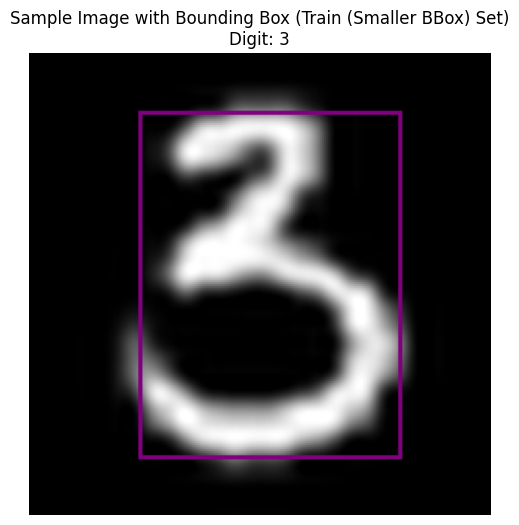

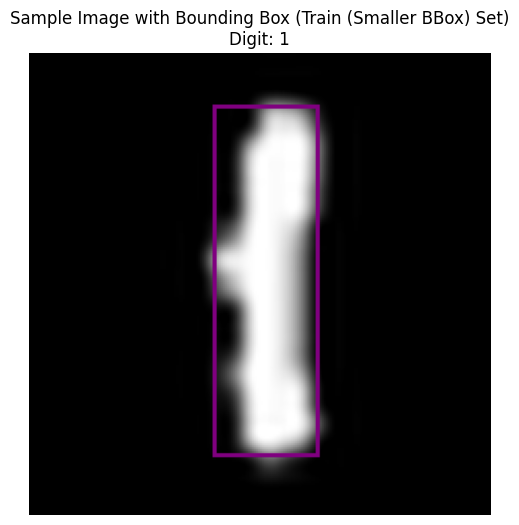

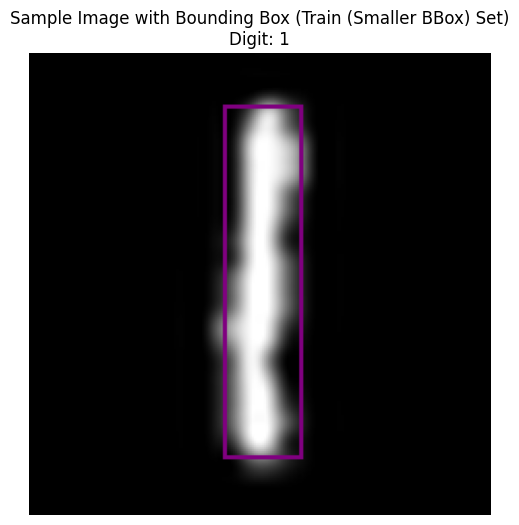

In [ ]:
# Filter the train_bbox_df_simple for bounding boxes with height < 175 and width < 137
small_bboxes_df = train_bbox_df_simple[
    (train_bbox_df_simple['bbox_height'] < 175) &
    (train_bbox_df_simple['bbox_width'] < 137)
]

print(f"Displaying 3 random samples from the {len(small_bboxes_df)} 'smaller' bounding boxes in the train set.")

# Plot a few samples
if not small_bboxes_df.empty:
    for i in range(min(3, len(small_bboxes_df))):
        plot_sample_with_bbox(small_bboxes_df, "Train (Smaller BBox)", color="purple")
else:
    print("No 'smaller' bounding boxes found to display in the train set based on the criteria.")

#### Image With Zero Bounding Box

In [ ]:
# Calculate width and height of bounding boxes
train_bbox_df_simple['bbox_width'] = train_bbox_df_simple['bbox_xmax'] - train_bbox_df_simple['bbox_xmin']
train_bbox_df_simple['bbox_height'] = train_bbox_df_simple['bbox_ymax'] - train_bbox_df_simple['bbox_ymin']

# Filter for zero-area bounding boxes
zero_area_bboxes = train_bbox_df_simple[(train_bbox_df_simple['bbox_width'] == 0) | (train_bbox_df_simple['bbox_height'] == 0)]

print(f"Found {len(zero_area_bboxes)} images with zero-area bounding boxes.")

if not zero_area_bboxes.empty:
    print("Sample of images with zero-area bounding boxes:")
    display(zero_area_bboxes.head())
else:
    print("No images found with zero-area bounding boxes.")

Found 0 images with zero-area bounding boxes.
No images found with zero-area bounding boxes.


#### Images With Drawn Bounding Boxes

In [ ]:
import os
import shutil
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random
import pandas as pd

# read simple_mask_bounding_box_train.csv
train_bbox_df_simple = pd.read_csv('/content/simple_masks_bounding_boxes_test.csv')

# Define the output directory for images with bounding boxes drawn on them
output_images_with_bbox_dir = "/content/test_images_with_drawn_bboxes"
os.makedirs(output_images_with_bbox_dir, exist_ok=True)

print(f"Saving images with drawn bounding boxes to: {output_images_with_bbox_dir}")

# Process and save images with bounding boxes
processed_count = 0
for index, row in train_bbox_df_simple.iterrows():
    try:
        image_path = row['image_path']
        bbox_xmin = row['bbox_xmin']
        bbox_ymin = row['bbox_ymin']
        bbox_xmax = row['bbox_xmax']
        bbox_ymax = row['bbox_ymax']
        digit_class = str(row['digit_class'])

        # Load the original image
        img = Image.open(image_path).convert('RGB') # Convert to RGB for drawing colored bounding box

        draw = ImageDraw.Draw(img)

        # Draw the bounding box
        draw.rectangle([bbox_xmin, bbox_ymin, bbox_xmax, bbox_ymax], outline="red", width=2)

        # Create subdirectories for digit classes if they don't exist
        class_output_dir = os.path.join(output_images_with_bbox_dir, digit_class)
        os.makedirs(class_output_dir, exist_ok=True)

        # Save the image with the drawn bounding box
        output_filename = os.path.basename(image_path).replace('.png', '_bbox.png')
        output_filepath = os.path.join(class_output_dir, output_filename)
        img.save(output_filepath)
        processed_count += 1

    except Exception as e:
        print(f"Could not process image {image_path}: {e}")

    if (processed_count % 10000) == 0 and processed_count > 0:
        print(f"Processed {processed_count} images with bounding boxes...")

print(f"Successfully processed {processed_count} images with bounding boxes.")

# Verify a few generated images
print(f"\nContents of a sample digit class folder in {output_images_with_bbox_dir}:")
sample_digit_class_path = os.path.join(output_images_with_bbox_dir, '0') # Assuming '0' is a digit class
if os.path.exists(sample_digit_class_path):
    print(os.listdir(sample_digit_class_path)[:5]) # Print first 5 filenames
else:
    print(f"Directory {sample_digit_class_path} not found.")

Saving images with drawn bounding boxes to: /content/test_images_with_drawn_bboxes
Processed 10000 images with bounding boxes...
Processed 20000 images with bounding boxes...
Processed 30000 images with bounding boxes...
Processed 40000 images with bounding boxes...
Successfully processed 40000 images with bounding boxes.

Contents of a sample digit class folder in /content/test_images_with_drawn_bboxes:
['03535_bbox.png', '03777_bbox.png', '03960_bbox.png', '02577_bbox.png', '00104_bbox.png']


#### Displaying a Batch of Images with Bounding Boxes (Train Set)

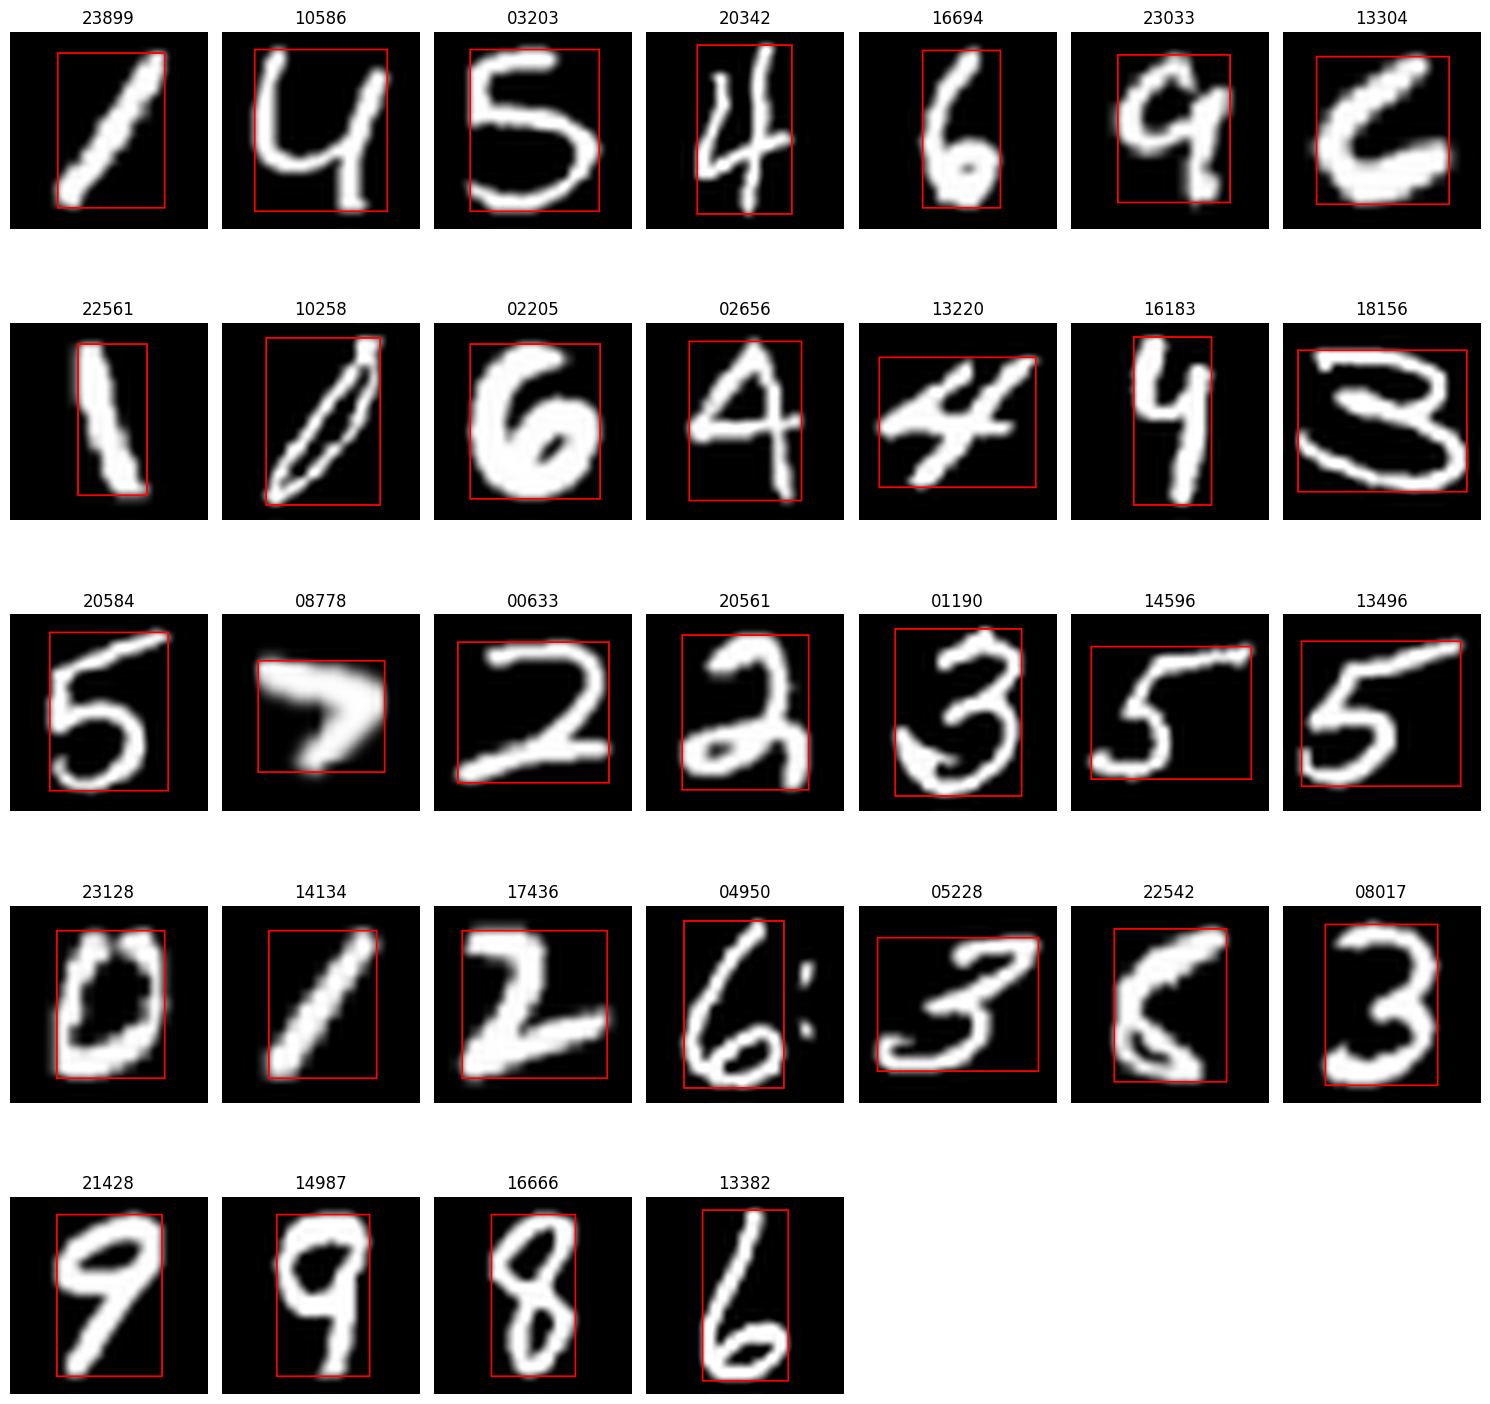

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

def display_image_batch(image_dir, num_images=32, seed=42):
    """Displays a batch of random images from a specified directory."""
    all_image_paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {image_dir}.")
        return

    # Use a fixed seed for reproducibility
    # random.seed(seed) # Removed to allow truly random selection each time
    selected_images = random.sample(all_image_paths, min(num_images, len(all_image_paths)))

    fig = plt.figure(figsize=(15, 15))
    rows = int(num_images**0.5) # Try to make a square grid
    cols = (num_images + rows - 1) // rows # Ensure enough columns

    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path).convert('RGB')
            ax = fig.add_subplot(rows, cols, i + 1)
            ax.imshow(img)
            ax.set_title(os.path.basename(img_path).split('_bbox')[0]) # Display original filename
            ax.axis('off')
        except Exception as e:
            print(f"Could not display image {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Define the directory containing images with drawn bounding boxes for the train set
train_images_with_bbox_dir = "/content/train_images_with_drawn_bboxes"

# Display a batch of 32 images
display_image_batch(train_images_with_bbox_dir, num_images=32, seed=42)

### Prepare Dataset for YOLO Training

In [42]:
import os
import pandas as pd
import shutil
from PIL import Image

# Define yolo dataset path
yolo_dataset_root = '/content/yolo_dataset'

# Assuming all images are 224x224 as resized in previous steps
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224

def create_yolo_dataset(df, split):
  """
  Prepares images and labels in YOLO format for a given DataFrame and split type.

  Args:
    df (pd.DataFrame): DataFrame containing image paths and bounding box annotations.
    split (str): 'train' or 'val', indicating the dataset split.
  """
  # Define train/test split dataset paths
  global yolo_dataset_root
  yolo_images_dir = os.path.join(yolo_dataset_root, 'images', f'{split}')
  yolo_labels_dir = os.path.join(yolo_dataset_root, 'labels', f'{split}')

  os.makedirs(yolo_images_dir, exist_ok=True)
  os.makedirs(yolo_labels_dir, exist_ok=True)

  processed_count = 0
  for index, row in df.iterrows():
      try:
          original_image_path = row['image_path']
          digit_class = int(row['digit_class']) # Convert class string to int for YOLO
          bbox_xmin = row['bbox_xmin']
          bbox_ymin = row['bbox_ymin']
          bbox_xmax = row['bbox_xmax']
          bbox_ymax = row['bbox_ymax']

          # Copy image to YOLO images directory
          image_filename = os.path.basename(original_image_path)
          yolo_image_path = os.path.join(yolo_images_dir, image_filename)

          # Ensure the source image actually exists. If not, it means an earlier step failed for this image.
          if not os.path.exists(original_image_path):
              print(f"Warning: Original image not found at {original_image_path}. Skipping.")
              continue

          shutil.copy(original_image_path, yolo_image_path)

          # Convert bounding box to YOLO format
          # (normalized center_x, center_y, width, height)
          center_x = (bbox_xmin + bbox_xmax) / 2
          center_y = (bbox_ymin + bbox_ymax) / 2
          bbox_width = bbox_xmax - bbox_xmin
          bbox_height = bbox_ymax - bbox_ymin

          # Normalize coordinates
          norm_center_x = center_x / IMAGE_WIDTH
          norm_center_y = center_y / IMAGE_HEIGHT
          norm_bbox_width = bbox_width / IMAGE_WIDTH
          norm_bbox_height = bbox_height / IMAGE_HEIGHT

          # Create YOLO label file
          label_filename = image_filename.replace('.png', '.txt').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.gif', '.txt') # Handle other image extensions
          yolo_label_path = os.path.join(yolo_labels_dir, label_filename)

          with open(yolo_label_path, 'w') as f:
              f.write(f"{digit_class} {norm_center_x} {norm_center_y} {norm_bbox_width} {norm_bbox_height}")

          processed_count += 1

      except Exception as e:
          print(f"Error processing {original_image_path} for {split} split: {e}")

      if (processed_count % 10000 == 0) and (processed_count > 0):
          print(f"Processed {processed_count} images for YOLO {split} dataset...")

  print(f"\nFinished preparing {processed_count} images and labels for YOLO {split} dataset.")

  # Verify a sample label file
  if processed_count > 0:
      sample_image_filename = os.path.basename(df.iloc[0]['image_path'])
      sample_label_filename = sample_image_filename.replace('.png', '.txt').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.gif', '.txt')
      sample_label_path = os.path.join(yolo_labels_dir, sample_label_filename)
      print(f"\nSample YOLO label content for {sample_label_filename} ({split} split):")
      if os.path.exists(sample_label_path):
          with open(sample_label_path, 'r') as f:
              print(f.read())
      else:
          print("Sample label file not found.")
  else:
      print(f"No images processed for {split} split to verify sample label.")



print(f"Preparing YOLO dataset for train split...")
# read simple_mask_bounding_box_train.csv
train_bbox_df = pd.read_csv('/content/simple_masks_bounding_boxes_train.csv')
create_yolo_dataset(train_bbox_df, split="train")

print(f"\nPreparing YOLO dataset for validation split...")
# read simple_mask_bounding_box_train.csv
val_bbox_df = pd.read_csv('/content/simple_masks_bounding_boxes_val.csv')
create_yolo_dataset(val_bbox_df, split="val")

print(f"\nPreparing YOLO dataset for test split...")
# read simple_mask_bounding_box_train.csv
test_bbox_df = pd.read_csv('/content/simple_masks_bounding_boxes_test.csv')
create_yolo_dataset(test_bbox_df, split="test")

Preparing YOLO dataset for train split...
Processed 10000 images for YOLO train dataset...
Processed 20000 images for YOLO train dataset...
Processed 30000 images for YOLO train dataset...
Processed 40000 images for YOLO train dataset...
Processed 50000 images for YOLO train dataset...
Processed 60000 images for YOLO train dataset...
Processed 70000 images for YOLO train dataset...
Processed 80000 images for YOLO train dataset...
Processed 90000 images for YOLO train dataset...
Processed 100000 images for YOLO train dataset...
Processed 110000 images for YOLO train dataset...
Processed 120000 images for YOLO train dataset...
Processed 130000 images for YOLO train dataset...
Processed 140000 images for YOLO train dataset...
Processed 150000 images for YOLO train dataset...
Processed 160000 images for YOLO train dataset...
Processed 170000 images for YOLO train dataset...
Processed 180000 images for YOLO train dataset...
Processed 190000 images for YOLO train dataset...

Finished prepari

### Create `data.yaml` for YOLO

In [2]:
import os

# Define the class names based on your digits (0-9)
class_names = [str(i) for i in range(10)]
num_classes = len(class_names)

# Create the data.yaml file content with absolute paths as requested by the user
data_yaml_content = f"""
train: /content/yolo_datasetimages/train  # Train images (absolute path)
val: /content/yolo_dataset/images/val    # Validation images (absolute path)
test: /content/yolo_dataset/images/test  # Test images (absolute path)

nc: {num_classes}  # Number of classes
names: {class_names} # Class names
"""

# Save the data.yaml file to a central location in /content
data_yaml_path = '/content/data.yaml'

# Ensure the parent directory exists before writing the file
os.makedirs(os.path.dirname(data_yaml_path), exist_ok=True)

with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"data.yaml created at: {data_yaml_path}")
print("\nContent of data.yaml:")
print(data_yaml_content)

data.yaml created at: /content/data.yaml

Content of data.yaml:

train: /content/yolo_dataset/content/yolo_dataset/images/train  # Train images (absolute path)
val: /content/yolo_dataset/content/yolo_dataset/images/val    # Validation images (absolute path)
test: /content/yolo_dataset/content/yolo_dataset/images/test  # Test images (absolute path)

nc: 10  # Number of classes
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] # Class names



### Install Ultralytics

In [3]:
# Install ultralytics if not already installed
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os

# Create DIR for Yolo Results on Google Drive
os.makedirs("/content/drive/MyDrive/yolo_results", exist_ok=True)

# Initialize the model
# Changed 'yolov11n.pt' to 'yolov8n.pt' for automatic download of pre-trained weights
model = YOLO('yolov8n.pt')

# Train the model
# You might need to adjust epochs, batch size, and other parameters
# based on your dataset and computational resources.
# The 'data' argument points to the data.yaml file we created.
results = model.train(data=data_yaml_path,
                      epochs=250,
                      imgsz=224,
                      batch=64,
                      lr0=1e-3,
                      lrf=1e-8,
                      weight_decay=5e-4,
                      save_period=1, # Saves model after every epoch
                      seed=42,
                      optimizer="auto",
                      device="cpu",
                      amp= True,
                      deterministic=False,
                      patience=5,
                      # Freeze the first 10 layers to speed up training on CPU
                      freeze=13,
                      # resume=True,
                      project="/content/drive/MyDrive/yolo_results", # Save results directly to MyDrive
                      exist_ok=True)

print("\nYOLOv8n training complete.")


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=False, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=13, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=1e-08, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective

#### Plot Box-Loss And Bounding-Box Loss on Train Set

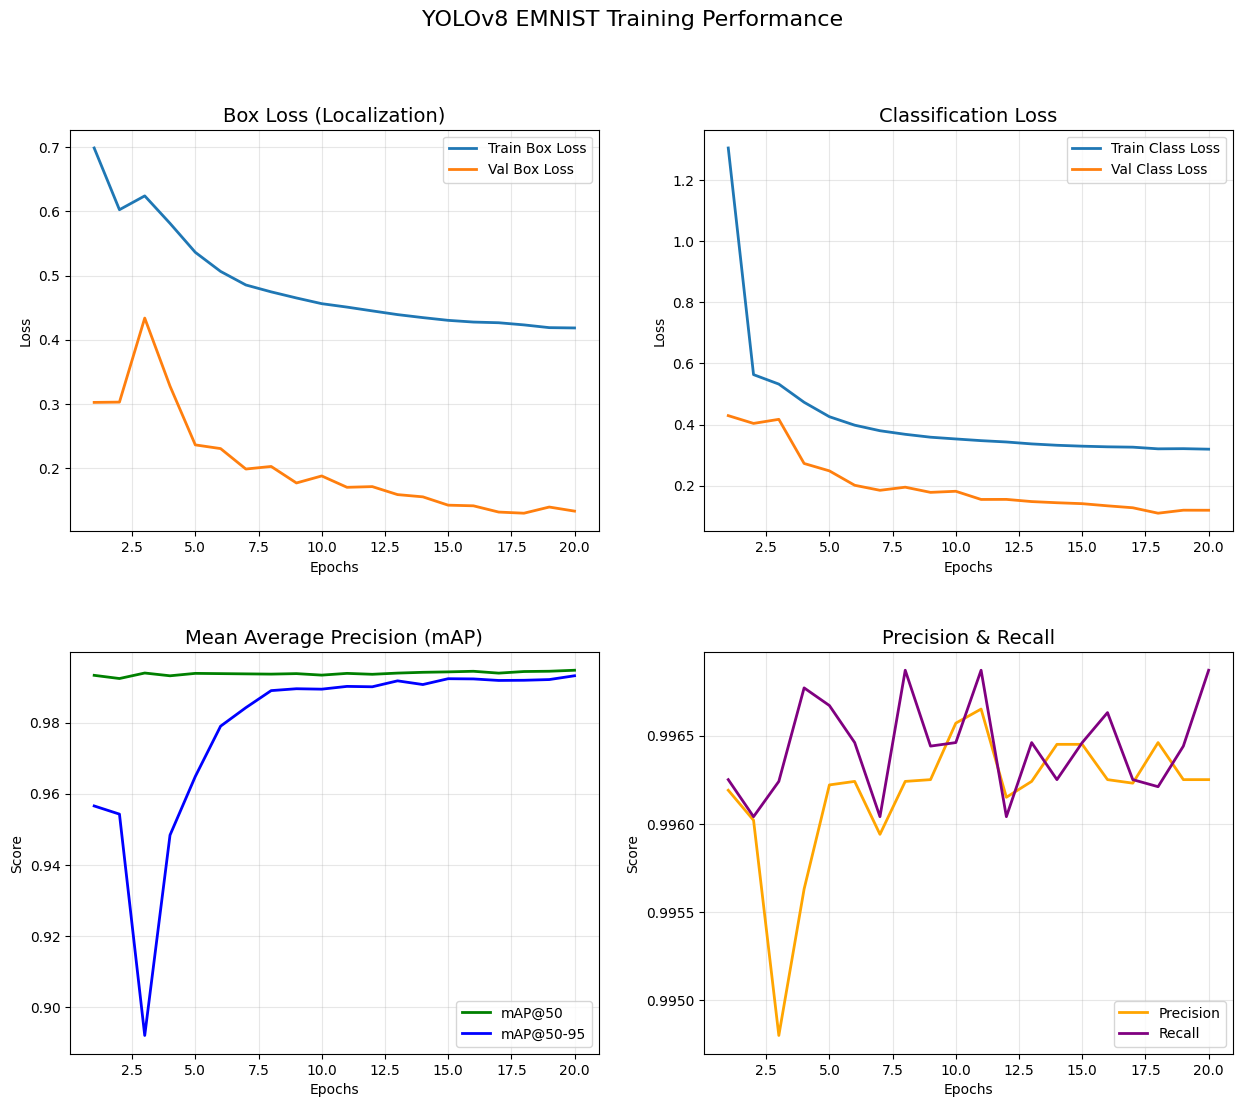

In [17]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

def plot_yolo_results(csv_path='results.csv'):
    # Load the results
    df = pd.read_csv(csv_path)

    # Strip whitespace from column names to avoid KeyErrors
    df.columns = [c.strip() for c in df.columns]

    # Create a 2x2 grid for plots
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # 1. Box Loss (Training vs Validation)
    axs[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', linewidth=2)
    axs[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', linewidth=2)
    axs[0, 0].set_title('Box Loss (Localization)', fontsize=14)
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)

    # 2. Classification Loss (Training vs Validation)
    axs[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', linewidth=2)
    axs[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', linewidth=2)
    axs[0, 1].set_title('Classification Loss', fontsize=14)
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    # 3. mAP Metrics
    # YOLOv8 uses mAP50-95 as the primary quality metric
    axs[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green', linewidth=2)
    axs[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='blue', linewidth=2)
    axs[1, 0].set_title('Mean Average Precision (mAP)', fontsize=14)
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Score')
    axs[1, 0].legend()
    axs[1, 0].grid(True, alpha=0.3)

    # 4. Precision and Recall
    axs[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='orange', linewidth=2)
    axs[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='purple', linewidth=2)
    axs[1, 1].set_title('Precision & Recall', fontsize=14)
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)

    plt.suptitle('YOLOv8 EMNIST Training Performance', fontsize=16)
    plt.savefig('yolo_evaluation_plots.png', dpi=300)
    plt.show()

plot_yolo_results('/content/drive/MyDrive/yolo_results/train/results.csv')

#### Evalaute Model on Test Set

In [25]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

model_path = "/content/drive/MyDrive/yolo_results/train/weights/best.pt"

# 1. Load your trained model
# Replace 'path/to/best.pt' with the actual path to your weights (e.g., 'runs/detect/train/weights/best.pt')
model = YOLO(model_path)

# 2. Run evaluation on the test split
# Ensure your data.yaml file has a 'test' path defined
metrics = model.val(data='/content/data.yaml',
                    split='test',
                    save=True, plots=True)

# 3. Print the results
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP75: {metrics.box.map75}")
print(f"Precision: {metrics.box.mp}") # Changed from metrics.box.precision
print(f"Recall: {metrics.box.mr}")      # Changed from metrics.box.recall


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 272.7±87.4 MB/s, size: 8.6 KB)
val: Scanning /content/yolo_dataset/content/yolo_dataset/labels/test.cache... 4000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4000/4000 699.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 250/250 1.6it/s 2:35
                   all       4000       4000      0.998      0.998      0.995      0.992
                     2       4000       4000      0.998      0.998      0.995      0.992
Speed: 0.3ms preprocess, 35.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP50-95: 0.9920769266271071
mAP50: 0.994696715411715
mAP75: 0.9932739934841359
Precision: 0.9979686586757832
Recall: 0.998
